In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Motor Insurance Fraud Detection Exercise

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ktnspr/py4ac/blob/main/06_fraud_detection_exercise.ipynb) [![Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/ktnspr/py4ac/blob/main/06_fraud_detection_exercise.ipynb)

## Problem Overview

In this exercise, you will work with a motor insurance dataset to build a fraud detection classifier. You have:

- **Dataset**: 10,000 motor insurance claims (`vehicle_fraud.csv`)
- **Features**: Policyholder information, vehicle details, and claim characteristics
- **Target**: `fraud` (0 = legitimate, 1 = fraudulent)
- **Challenge**: The overall fraud rate is approximately 25% — this is a **class imbalance** problem

## Your Mission

Work through three phases to understand fraud patterns and build an effective classifier:

### **Phase 1: Exploration**
Understand the data distribution, identify missing values, visualize relationships between features and fraud.

### **Phase 2: Modelling**
Prepare features, engineer new predictors, and train classification models.

### **Phase 3: Evaluation**
Assess model performance and identify the most important fraud indicators.

---

In [2]:
# Colab/Kaggle setup: fetch data file if not running locally
import sys, os
if "google.colab" in sys.modules or "KAGGLE_KERNEL_RUN_TYPE" in os.environ:
    !wget -qN https://raw.githubusercontent.com/ktnspr/py4ac/main/vehicle_fraud.csv

In [3]:
df = pd.read_csv("vehicle_fraud.csv")
df.head()

,policyholder_age,occupation,region,schufa_score,customer_since_years,vehicle_value,vehicle_type,coverage_type,number_of_prior_claims,claim_amount,police_report,witnesses_present,reporting_delay_days,fraud
0,37,Student,PLZ_04,605,0,76917.611418,Compact,Partial coverage,1,12634.356313,1,0,31,0
1,46,Student,PLZ_01,636,8,22116.794440,Luxury,Liability,3,19670.366039,0,0,22,1
2,37,Unemployed,PLZ_06,467,8,54037.879642,Compact,Comprehensive,2,11888.239486,0,1,42,0
3,44,Student,PLZ_08,566,9,68533.231831,Mid-range,Comprehensive,3,5804.723064,0,1,58,0
4,69,Student,PLZ_01,465,23,54848.694293,Luxury,Partial coverage,2,3916.151998,1,1,30,0


In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   policyholder_age        10000 non-null  int64  
 1   occupation              10000 non-null  object 
 2   region                  10000 non-null  object 
 3   schufa_score            10000 non-null  int64  
 4   customer_since_years    10000 non-null  int64  
 5   vehicle_value           10000 non-null  float64
 6   vehicle_type            10000 non-null  object 
 7   coverage_type           10000 non-null  object 
 8   number_of_prior_claims  10000 non-null  int64  
 9   claim_amount            10000 non-null  float64
 10  police_report           10000 non-null  int64  
 11  witnesses_present       10000 non-null  int64  
 12  reporting_delay_days    10000 non-null  int64  
 13  fraud                   10000 non-null  int64  
dtypes: float64(2), int64(8), object(4)
memo

In [10]:
display(df.describe())

,policyholder_age,schufa_score,customer_since_years,vehicle_value,number_of_prior_claims,claim_amount,police_report,witnesses_present,reporting_delay_days,fraud
count,10000.00000,10000.000000,10000.0000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,49.70040,598.055600,14.4924,40427.082066,1.633700,11598.656159,0.496900,0.511400,24.82600,0.240100
std,15.12421,113.141432,7.6756,22761.958229,1.351927,8607.032212,0.500015,0.499895,14.58611,0.427165
min,18.00000,300.000000,0.0000,1022.891555,0.000000,117.212704,0.000000,0.000000,0.00000,0.000000
25%,39.00000,520.000000,9.0000,20549.323463,0.000000,5502.204756,0.000000,0.000000,14.00000,0.000000
50%,50.00000,598.000000,14.0000,40618.755089,2.000000,9512.312532,0.000000,1.000000,25.00000,0.000000
75%,60.00000,676.000000,20.0000,59976.606521,3.000000,15391.401398,1.000000,1.000000,35.00000,0.000000
max,80.00000,850.000000,30.0000,79984.656782,5.000000,72722.561056,1.000000,1.000000,60.00000,1.000000


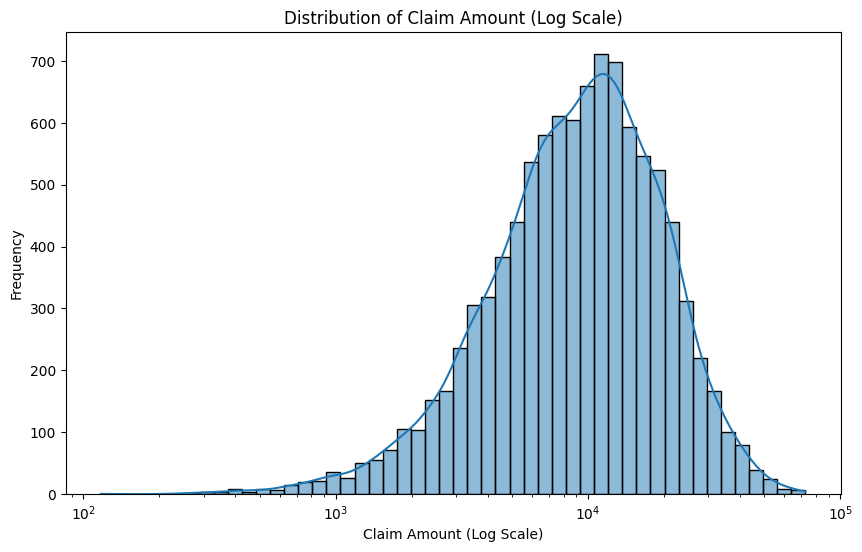

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(df['claim_amount'], kde=True, bins=50, log_scale=True)
plt.title('Distribution of Claim Amount (Log Scale)')
plt.xlabel('Claim Amount (Log Scale)')
plt.ylabel('Frequency')
plt.show()

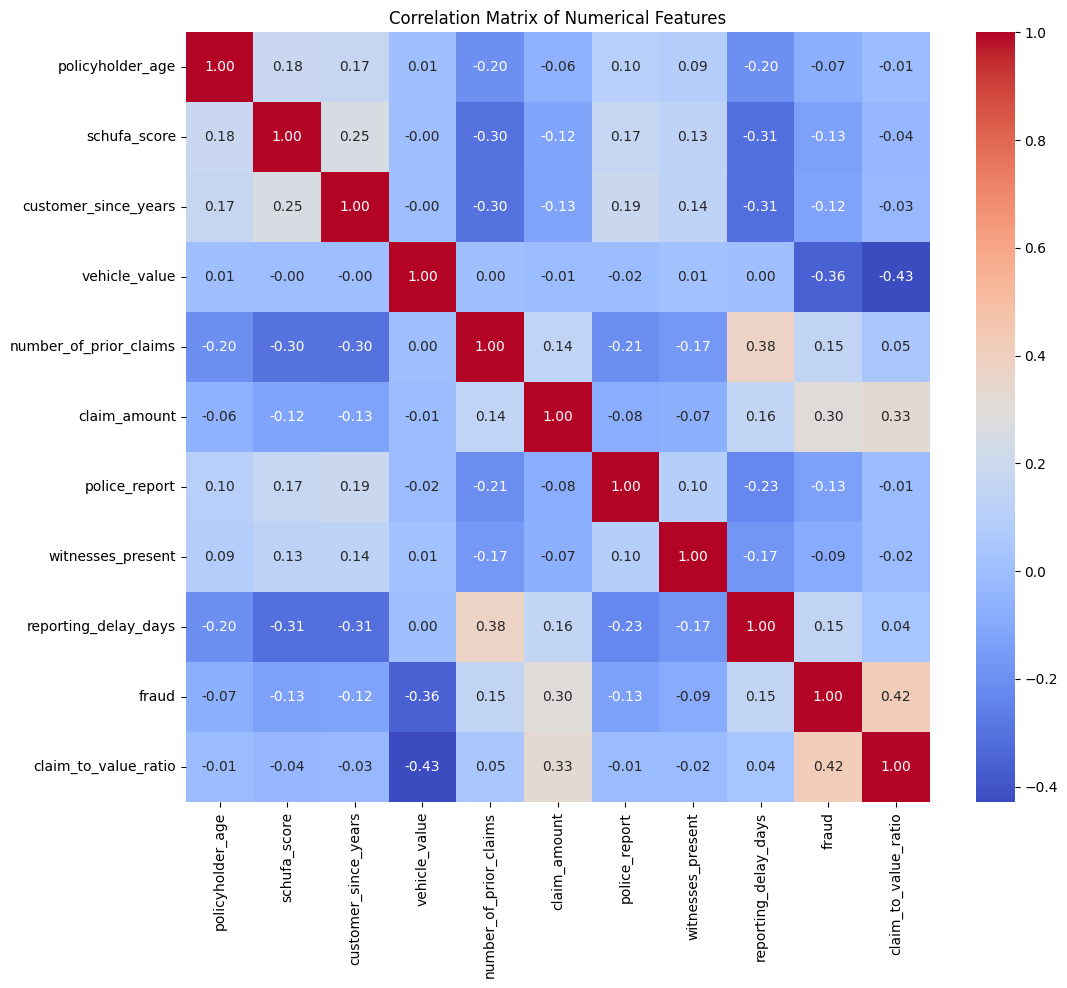

In [25]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

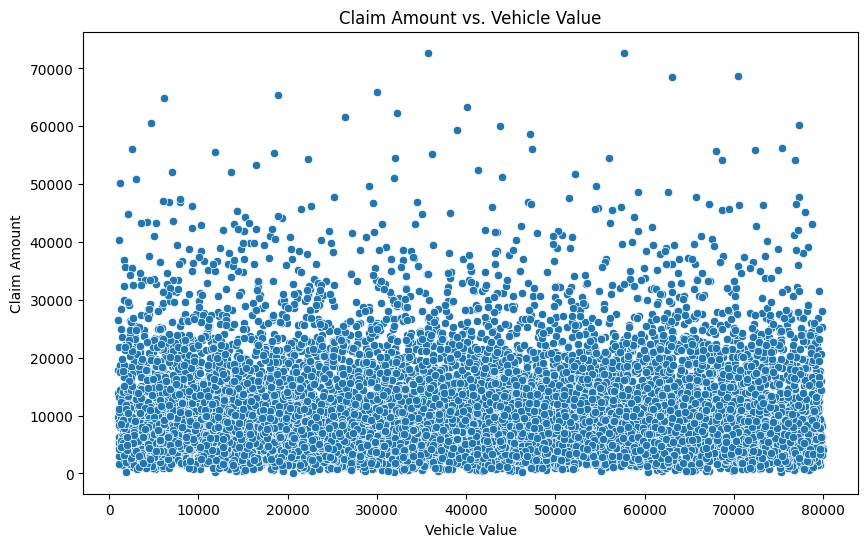

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='vehicle_value', y='claim_amount', data=df)
plt.title('Claim Amount vs. Vehicle Value')
plt.xlabel('Vehicle Value')
plt.ylabel('Claim Amount')
plt.show()

In [15]:
df['claim_to_value_ratio'] = df['claim_amount'] / df['vehicle_value']
display(df[['claim_amount', 'vehicle_value', 'claim_to_value_ratio']].head())

,claim_amount,vehicle_value,claim_to_value_ratio
0,12634.356313,76917.611418,0.164258
1,19670.366039,22116.794440,0.889386
2,11888.239486,54037.879642,0.219998
3,5804.723064,68533.231831,0.084699
4,3916.151998,54848.694293,0.071399


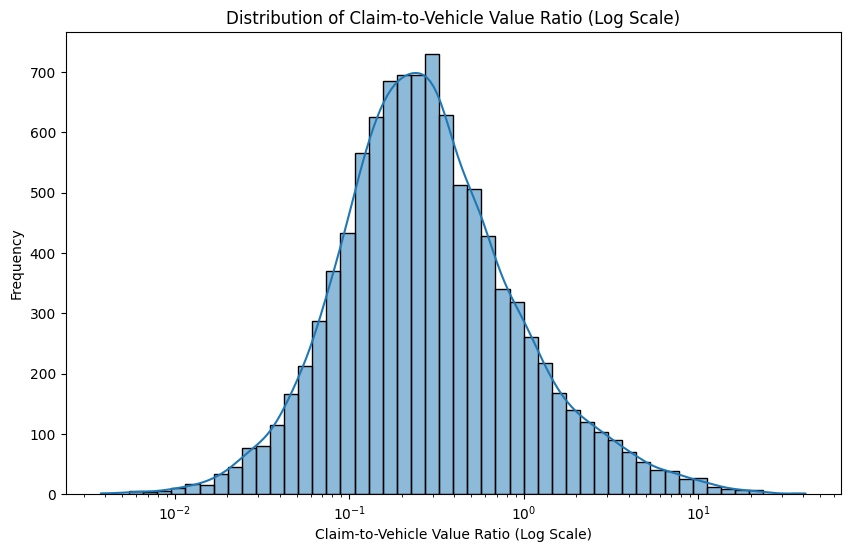

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(df['claim_to_value_ratio'], kde=True, bins=50, log_scale=True)
plt.title('Distribution of Claim-to-Vehicle Value Ratio (Log Scale)')
plt.xlabel('Claim-to-Vehicle Value Ratio (Log Scale)')
plt.ylabel('Frequency')
plt.show()

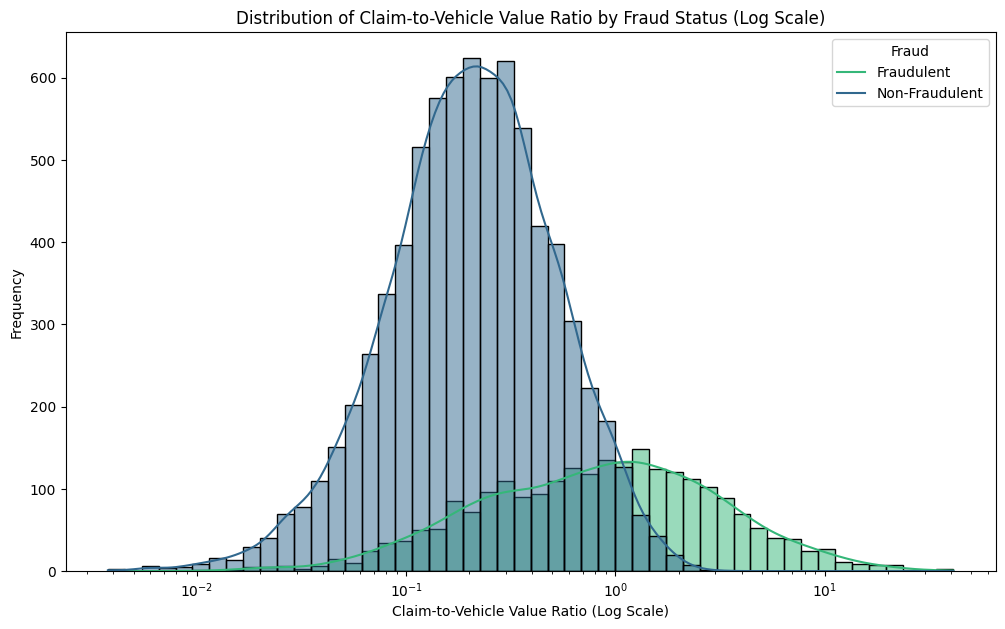

In [26]:
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='claim_to_value_ratio', hue='fraud', kde=True, bins=50, log_scale=True, palette='viridis')
plt.title('Distribution of Claim-to-Vehicle Value Ratio by Fraud Status (Log Scale)')
plt.xlabel('Claim-to-Vehicle Value Ratio (Log Scale)')
plt.ylabel('Frequency')
plt.legend(title='Fraud', labels=['Fraudulent', 'Non-Fraudulent'])
plt.show()

## Phase 1: Exploration

Explore the dataset. Look at the shape, data types, summary statistics, distributions, correlations, and relationships between features and the target variable `fraud`. Are there any missing values? What patterns do you notice?

> ### 🔍 Guiding Questions
>
> As you explore, try to answer these questions:
> 1. How many rows and columns does the dataset have? Which columns are numeric, which are categorical?
> 2. What is the **fraud rate**? Is the dataset balanced or imbalanced?
> 3. Is `claim_amount` normally distributed, or is it skewed? (Try a histogram!)
> 4. Do fraudulent claims look different from legitimate ones? Compare distributions using **boxplots grouped by `fraud`** for numeric columns.
> 5. Are there any columns that seem **more correlated with fraud** than others? Think about which features a fraudster might influence.
>
> **Useful methods:** `df.shape`, `df.info()`, `df.describe()`, `df['fraud'].value_counts()`, `df.hist()`, `df.boxplot(by=...)`, `sns.heatmap(df.corr())`

In [24]:
# Check dataset shape and info
# Hint: Start with df.shape, df.info(), and df.describe()
# Hint: Check the fraud rate with df['fraud'].value_counts(normalize=True)
# -> What percentage of claims are fraudulent? Is this balanced?
print(df.shape)
print(df.info())
display(df.describe())
print("\nFraud Rate:")
print(df['fraud'].value_counts(normalize=True))

(10000, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   policyholder_age        10000 non-null  int64  
 1   occupation              10000 non-null  object 
 2   region                  10000 non-null  object 
 3   schufa_score            10000 non-null  int64  
 4   customer_since_years    10000 non-null  int64  
 5   vehicle_value           10000 non-null  float64
 6   vehicle_type            10000 non-null  object 
 7   coverage_type           10000 non-null  object 
 8   number_of_prior_claims  10000 non-null  int64  
 9   claim_amount            10000 non-null  float64
 10  police_report           10000 non-null  int64  
 11  witnesses_present       10000 non-null  int64  
 12  reporting_delay_days    10000 non-null  int64  
 13  fraud                   10000 non-null  int64  
 14  claim_to_value_ratio    100

,policyholder_age,schufa_score,customer_since_years,vehicle_value,number_of_prior_claims,claim_amount,police_report,witnesses_present,reporting_delay_days,fraud,claim_to_value_ratio
count,10000.00000,10000.000000,10000.0000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,49.70040,598.055600,14.4924,40427.082066,1.633700,11598.656159,0.496900,0.511400,24.82600,0.240100,0.657759
std,15.12421,113.141432,7.6756,22761.958229,1.351927,8607.032212,0.500015,0.499895,14.58611,0.427165,1.535905
min,18.00000,300.000000,0.0000,1022.891555,0.000000,117.212704,0.000000,0.000000,0.00000,0.000000,0.003764
25%,39.00000,520.000000,9.0000,20549.323463,0.000000,5502.204756,0.000000,0.000000,14.00000,0.000000,0.131065
50%,50.00000,598.000000,14.0000,40618.755089,2.000000,9512.312532,0.000000,1.000000,25.00000,0.000000,0.259930
75%,60.00000,676.000000,20.0000,59976.606521,3.000000,15391.401398,1.000000,1.000000,35.00000,0.000000,0.564906
max,80.00000,850.000000,30.0000,79984.656782,5.000000,72722.561056,1.000000,1.000000,60.00000,1.000000,41.112149



Fraud Rate:
fraud
0    0.7599
1    0.2401
Name: proportion, dtype: float64


In [22]:
# Visualize distributions and correlations
# Hint: Plot a histogram of claim_amount — notice the shape of the distribution.
#       Right-skewed data may benefit from a log transform later.
# Hint: Use sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)
#       to see which numeric features correlate with each other and with fraud.


Mean values grouped by fraud status:


,policyholder_age,schufa_score,customer_since_years,vehicle_value,number_of_prior_claims,claim_amount,police_report,witnesses_present,reporting_delay_days,claim_to_value_ratio
fraud,,,,,,,,,,
0,50.291881,606.586919,15.018818,45057.189875,1.519410,10158.963886,0.534807,0.537571,23.604948,0.298731
1,47.828405,571.054561,12.826322,25773.109038,1.995419,16155.183268,0.376926,0.428571,28.690546,1.794058



Boxplot for Claim Amount by Fraud Status:


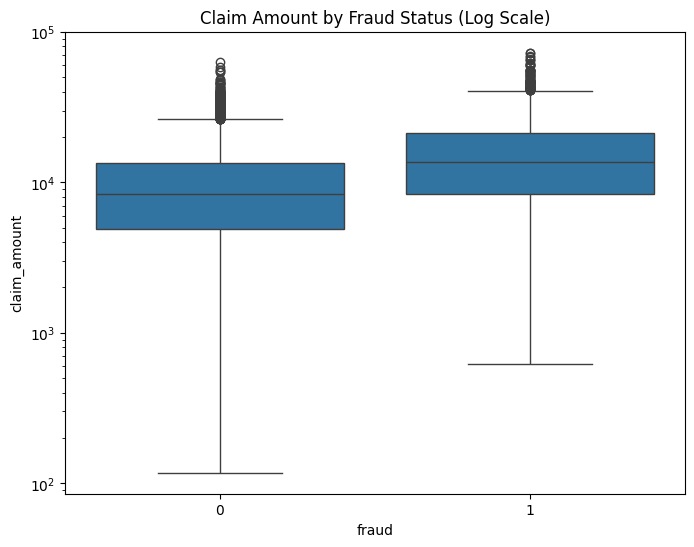


Boxplot for Reporting Delay Days by Fraud Status:


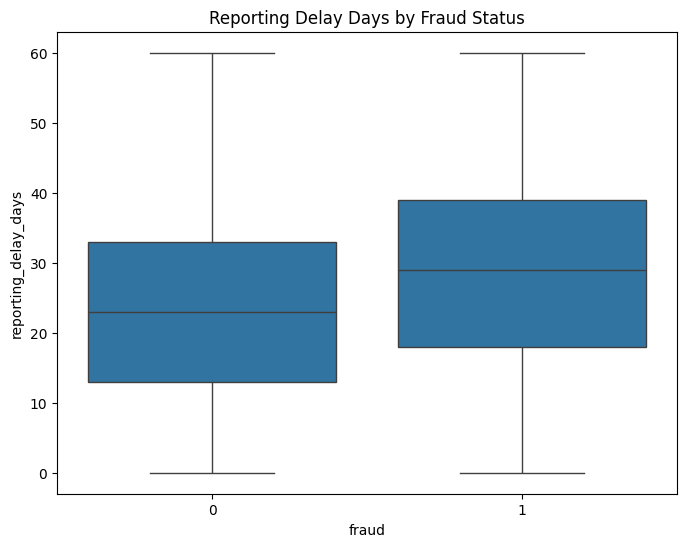


Fraud rate based on police report and witnesses present:


witnesses_present,0,1
police_report,,
0,0.337033,0.251289
1,0.211177,0.159368


In [20]:
# Analyze fraud patterns
# What differences do you see between fraudulent and legitimate claims?
# Hint: Compare means by fraud status: df.groupby('fraud').mean(numeric_only=True)
# Hint: Try boxplots — e.g. df.boxplot(column='claim_amount', by='fraud')
# Hint: Look at police_report and witnesses_present — are they different for fraud=1?

print("Mean values grouped by fraud status:")
display(df.groupby('fraud').mean(numeric_only=True))

print("\nBoxplot for Claim Amount by Fraud Status:")
plt.figure(figsize=(8, 6))
sns.boxplot(x='fraud', y='claim_amount', data=df)
plt.title('Claim Amount by Fraud Status (Log Scale)')
plt.yscale('log') # Apply logarithmic scale to the y-axis
plt.show()

print("\nBoxplot for Reporting Delay Days by Fraud Status:")
plt.figure(figsize=(8, 6))
sns.boxplot(x='fraud', y='reporting_delay_days', data=df)
plt.title('Reporting Delay Days by Fraud Status')
plt.show()

print("\nFraud rate based on police report and witnesses present:")
display(df.groupby(['police_report', 'witnesses_present'])['fraud'].mean().unstack())

In [ ]:
# Additional exploratory analysis
# Hint: Think about COMBINATIONS of features. For example:
#   - What is the fraud rate when BOTH police_report==0 AND witnesses_present==0?
#   - Do new customers (low customer_since_years) with many prior claims show higher fraud?
# Hint: Use df.groupby([col1, col2])['fraud'].mean() to compute fraud rates by group


## Phase 2: Modelling

Encode categorical features, create new features if useful, split the data into training and test sets, and train one or more classifiers (e.g., Logistic Regression, Random Forest, XGBoost).

> ### 🛠️ Step-by-Step Guide
>
> 1. **Handle categorical columns** — Columns like `occupation`, `region`, `vehicle_type`, `coverage_type` are strings. Models need numbers. Look into `pd.get_dummies()` with `drop_first=True`.
> 2. **Engineer new features** — Can you combine existing columns into something more meaningful? (See tips below.)
> 3. **Split into train/test** — Use `train_test_split()`. Since fraud is rare, use `stratify=y` to keep the fraud ratio consistent in both sets.
> 4. **Scale if needed** — Some models (Logistic Regression, Neural Networks) work better with standardized features. Tree-based models (Random Forest, XGBoost) don't need scaling.
> 5. **Train your model(s)** — Start simple (e.g., Random Forest) and iterate.

> ### 💡 Tips for Feature Engineering
>
> Consider these feature engineering ideas:
> - **Claim-to-value ratio**: `claim_amount / vehicle_value` — fraudsters may claim disproportionate amounts
> - **Suspicious claim patterns**: Combine `police_report` and `witnesses_present` — what happens when both are missing?
> - **Customer risk profile**: Combine `customer_since_years` and `number_of_prior_claims` — are new customers with many claims riskier?
> - **Transform skewed features**: Use `np.log1p(claim_amount)` to handle right-skewed distributions
>
> ### ⚠️ Handling Class Imbalance
>
> With only ~25% fraud, a model that always predicts "no fraud" gets ~75% accuracy but catches zero fraud! To address this:
> - Use `class_weight='balanced'` in scikit-learn models (e.g., `RandomForestClassifier(class_weight='balanced')`)
> - For XGBoost, use `scale_pos_weight` (ratio of negative to positive samples)
> - Focus on **Recall** and **F1-Score** for the fraud class, not just accuracy

In [23]:
# Prepare the data: handle missing values, encode categories
# Hint: Use pd.get_dummies(df, columns=[...], drop_first=True) to one-hot encode
#       the categorical columns: 'occupation', 'region', 'vehicle_type', 'coverage_type'
# Hint: Make a copy first with df_encoded = df.copy() so your original df stays clean
df_encoded = df.copy()
df_encoded = pd.get_dummies(df_encoded, columns=['occupation', 'region', 'vehicle_type', 'coverage_type'], drop_first=True)
display(df_encoded.head())

,policyholder_age,schufa_score,customer_since_years,vehicle_value,number_of_prior_claims,claim_amount,police_report,witnesses_present,reporting_delay_days,fraud,...,region_PLZ_07,region_PLZ_08,region_PLZ_09,region_PLZ_10,vehicle_type_Luxury,vehicle_type_Mid-range,vehicle_type_SUV,vehicle_type_Sports car,coverage_type_Liability,coverage_type_Partial coverage
0,37,605,0,76917.611418,1,12634.356313,1,0,31,0,...,False,False,False,False,False,False,False,False,False,True
1,46,636,8,22116.794440,3,19670.366039,0,0,22,1,...,False,False,False,False,True,False,False,False,True,False
2,37,467,8,54037.879642,2,11888.239486,0,1,42,0,...,False,False,False,False,False,False,False,False,False,False
3,44,566,9,68533.231831,3,5804.723064,0,1,58,0,...,False,True,False,False,False,True,False,False,False,False
4,69,465,23,54848.694293,2,3916.151998,1,1,30,0,...,False,False,False,False,True,False,False,False,False,True


In [ ]:
# Feature engineering
# Create new features that might improve prediction
# Hint: Think about RATIOS — e.g., claim_amount relative to vehicle_value
# Hint: Think about INTERACTIONS — combine two binary/categorical features into one
# Hint: Think about TRANSFORMS — log-transform skewed columns like claim_amount
#       (remember np.log1p handles zeros safely)


In [ ]:
# Split data and train classifier(s)
# Hint: Separate features (X) and target (y) first:
#   X = df_encoded.drop(columns=['fraud'])
#   y = df_encoded['fraud']
# Hint: Use train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
#       The stratify parameter ensures the fraud ratio is the same in train and test.
# Hint: For a first model, try RandomForestClassifier(n_estimators=100, class_weight='balanced')


In [ ]:
# Additional modelling steps
# Hint: Want to try a second model? Models that need scaling (Logistic Regression, MLP):
#   from sklearn.preprocessing import StandardScaler
#   scaler = StandardScaler()
#   X_train_scaled = scaler.fit_transform(X_train)  # fit on train only!
#   X_test_scaled = scaler.transform(X_test)         # transform test with same scaler
# Hint: XGBoost handles imbalance with scale_pos_weight:
#   scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()


## Phase 3: Evaluation

Evaluate your model(s) using appropriate metrics. Which features are most predictive of fraud? How confident are you in the model's predictions?

> ### What to look at
>
> - **`classification_report(y_test, y_pred)`** — Shows precision, recall, and F1-score for each class. Pay special attention to the **fraud row** (class 1).
> - **Confusion Matrix** — How many fraud cases did you catch (True Positives)? How many did you miss (False Negatives)?
> - **ROC-AUC** — Use `roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])` to measure ranking quality. This is especially meaningful for imbalanced data.
> - **Feature Importance** — Tree-based models have `.feature_importances_`. Or try `sklearn.inspection.permutation_importance()` which works with any model.
>
> Remember: **Accuracy is misleading** with imbalanced data. A model predicting "no fraud" always gets ~92% accuracy but is useless!

In [ ]:
# Evaluate your model on the test set
# Report key metrics: accuracy, precision, recall, F1-score, ROC-AUC
# Hint: y_pred = model.predict(X_test)
#       print(classification_report(y_test, y_pred, target_names=['Non-Fraud', 'Fraud']))
# Hint: For ROC-AUC, you need predicted probabilities:
#       from sklearn.metrics import roc_auc_score
#       y_proba = model.predict_proba(X_test)[:, 1]  # probability of class 1
#       print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")


In [ ]:
# Feature importance analysis
# Which features matter most for fraud detection?
# Hint (tree-based models): importances = model.feature_importances_
#   Create a bar chart of the top 10–15 features sorted by importance.
# Hint (any model): from sklearn.inspection import permutation_importance
#   perm = permutation_importance(model, X_test, y_test, n_repeats=20, scoring='roc_auc')
#   This shuffles each feature and measures how much performance drops.
# -> Do your engineered features appear among the top features?


In [ ]:
# Confusion matrix and additional insights
# Hint: from sklearn.metrics import confusion_matrix
#       cm = confusion_matrix(y_test, y_pred)
#       sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#                   xticklabels=['Non-Fraud', 'Fraud'],
#                   yticklabels=['Non-Fraud', 'Fraud'])
# -> Look at the bottom row: how many actual fraud cases did your model catch vs. miss?


## Bonus Challenge

Try comparing multiple classifiers:
- Logistic Regression (`class_weight='balanced'`, needs scaled data)
- Random Forest (`class_weight='balanced'`, no scaling needed)
- Gradient Boosting (`XGBClassifier` with `scale_pos_weight`, no scaling needed)
- Neural Networks (`MLPClassifier` with `early_stopping=True`, needs scaled data)

Can you achieve an **F1-score above 0.50** on the fraud class? What trade-offs do you notice between precision and recall?

> ### Going Further
>
> - **Threshold tuning**: By default, the model flags fraud when `predict_proba >= 0.5`. But you can lower this threshold to catch more fraud (higher recall) at the cost of more false alarms (lower precision). Try `(model.predict_proba(X_test)[:, 1] >= 0.3).astype(int)` — what changes?
> - **Compare models in a table**: Store each model's metrics in a dictionary and display them as a DataFrame for easy comparison.
> - **`precision_recall_curve`** from sklearn shows you the full trade-off — very useful for deciding on the right threshold for a business context.